# 55 Sale & Rent Models — XGBoost definitivo

Modelos XGBoost definitivos para **sale** y **rent**.

**Sale** (de `53_boost_sale`):
- Hiperparámetros hardcodeados (R²≈0.81), target `log_precio`
- Limpieza: IQR×1.5 sobre `log_precio` + suelo `precio_m2 ≥ 1000 €/m²` (elimina ruinas/anomalías)

**Rent** (de `53_boost_rent`):
- Hiperparámetros Optuna (100 trials, CV-RMSE), target `log_precio`
- Limpieza: vacacionales (`precio_m2 > 18`) + anomalías baratas (`precio_m2 < 6`) + IQR×1.5
- Features adicionales: `es_exterior_piso`, `tiene_ascensor_piso`
- Sin features derivadas del precio (evita leakage)

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
TARGET_COL   = "log_precio"
CV_FOLDS     = 5
IQR_FACTOR   = 1.5
MIN_MUNI_OBS = 10

# Sale: suelo precio_m2 — elimina ruinas, rurales extremas y errores
SALE_PRECIO_M2_MIN          = 1000   # €/m²

# Rent: filtros de precio_m2 simétricos
RENT_PRECIO_M2_VACACIONAL   = 18.0   # €/m²/mes — por encima: vacacional
RENT_PRECIO_M2_MIN          = 6.0    # €/m²/mes — por debajo: anomalía / garaje / error

# ── Rutas ─────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SALE_PATH = PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv"

print(f"Sale dataset: {SALE_PATH}")

Sale dataset: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale_idealistaAPI.csv


In [8]:
# ── Features base ──────────────────────────────────────────────────────────────
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "planta_num",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
]

# ── Hiperparámetros XGBoost ────────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

print("Hiperparámetros XGBoost:")
for k, v in XGB_PARAMS.items():
    print(f"  {k}: {v}")

Hiperparámetros XGBoost:
  n_estimators: 400
  max_depth: 4
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 3
  reg_lambda: 3
  random_state: 42
  n_jobs: -1
  verbosity: 0


In [9]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def remove_outliers_iqr(df: pd.DataFrame) -> pd.DataFrame:
    q1, q3 = df[TARGET_COL].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = df[TARGET_COL].between(q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr)
    print(f"  Outliers eliminados: {(~mask).sum()} / {len(df)} ({(~mask).mean()*100:.1f}%)")
    return df[mask].copy()


def build_X(df: pd.DataFrame) -> tuple:
    """Construye X con todas las features + municipio_* OHE agrupando raros."""
    df2 = df.copy()

    base = [f for f in BASE_FEATURES if f in df2.columns]

    mun_cols = sorted([c for c in df2.columns if c.startswith("municipio_")])
    if mun_cols:
        counts = df2[mun_cols].sum()
        small  = counts[counts < MIN_MUNI_OBS].index.tolist()
        if small:
            df2["municipio_otros"] = df2[small].max(axis=1)
            df2 = df2.drop(columns=small)
        mun_final = sorted(c for c in df2.columns if c.startswith("municipio_"))
    else:
        mun_final = []

    all_feats = base + [m for m in mun_final if m not in base]
    X = df2[all_feats].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X, all_feats


def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse  = mean_squared_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(float(mse), 5)],
        "RMSE": [round(float(np.sqrt(mse)), 5)],
        "MAE":  [round(float(mean_absolute_error(y_real, y_pred)), 5)],
        "R2":   [round(float(r2_score(y_real, y_pred)), 5)],
        "MAPE": [round(float(mean_absolute_percentage_error(y_real, y_pred)), 5)],
    })


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")

    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances, feature_names, title, top_n=20):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


print("Funciones cargadas.")

Funciones cargadas.


## Modelo SALE

DATASET: SALE
Filas originales: 2694
  IQR×1.5 log_precio eliminados: 0 (0.0%)
  Suelo precio_m2 < 1000 €/m² eliminados: 151 (5.6%)
Filas tras limpieza: 2543
Features (48): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Laredo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Mogro', 'municipio_Noja', 'municipio_Ortuella', 'municipio_Piéla

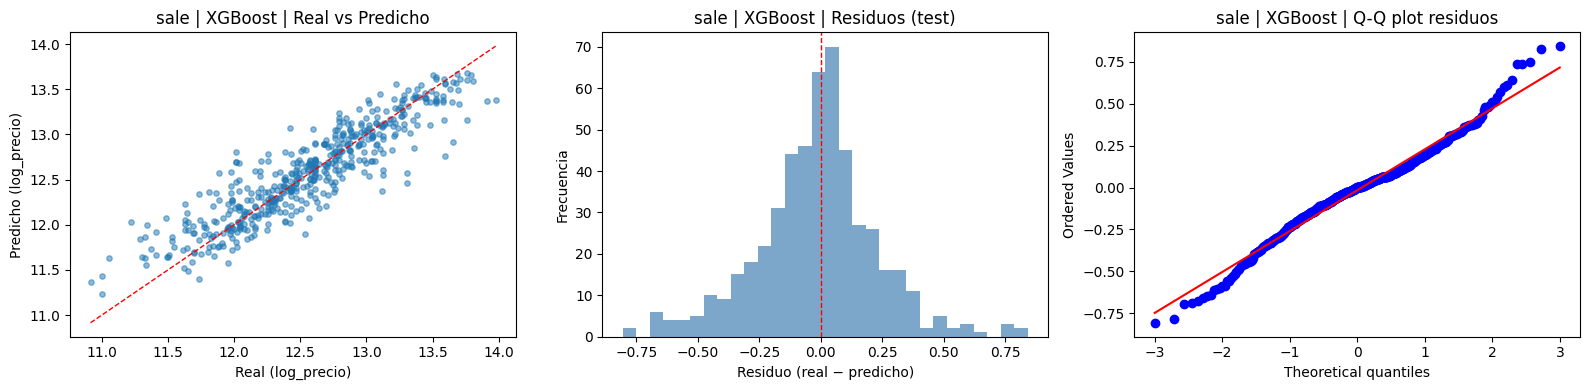

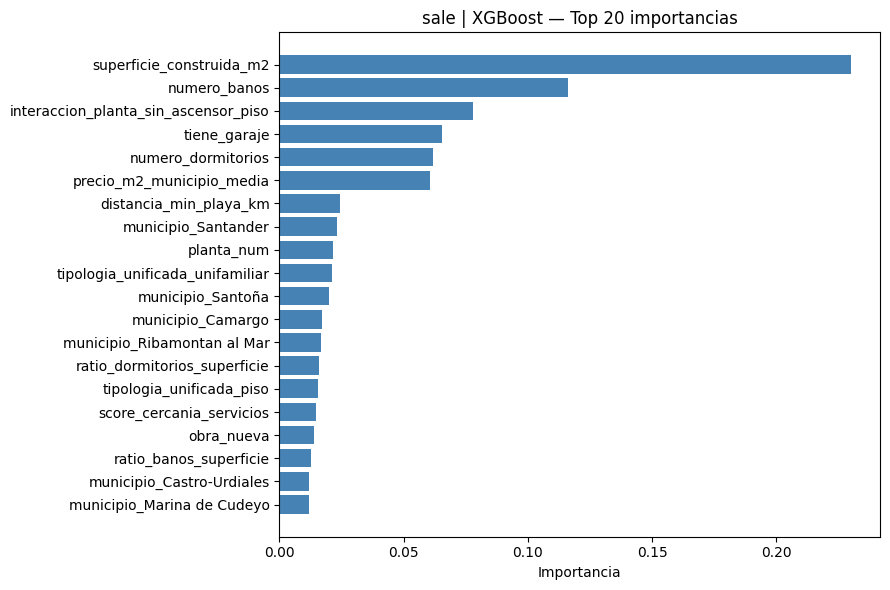

,feature,importance
0,superficie_construida_m2,0.230198
2,numero_banos,0.116207
12,interaccion_planta_sin_ascensor_piso,0.077980
4,tiene_garaje,0.065367
1,numero_dormitorios,0.061679
9,precio_m2_municipio_media,0.060737
6,distancia_min_playa_km,0.024354
38,municipio_Santander,0.023344
3,planta_num,0.021423
16,tipologia_unificada_unifamiliar,0.021112


In [10]:
print("=" * 90)
print("DATASET: SALE")
print("=" * 90)

# ── Carga ──────────────────────────────────────────────────────────────────────
df_sale = pd.read_csv(SALE_PATH)
df_sale = df_sale[df_sale[TARGET_COL].notna()].copy()
print(f"Filas originales: {len(df_sale)}")

# ── Paso 1: IQR×1.5 sobre log_precio ─────────────────────────────────────────
q1, q3 = df_sale[TARGET_COL].quantile([0.25, 0.75])
iqr = q3 - q1
mask_iqr = df_sale[TARGET_COL].between(q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr)
print(f"  IQR×{IQR_FACTOR} log_precio eliminados: {(~mask_iqr).sum()} ({(~mask_iqr).mean()*100:.1f}%)")
df_sale = df_sale[mask_iqr].copy()

# ── Paso 2: suelo precio_m2 ───────────────────────────────────────────────────
mask_m2 = df_sale["precio_m2"] >= SALE_PRECIO_M2_MIN
print(f"  Suelo precio_m2 < {SALE_PRECIO_M2_MIN} €/m² eliminados: {(~mask_m2).sum()} ({(~mask_m2).mean()*100:.1f}%)")
df_sale = df_sale[mask_m2].copy()
print(f"Filas tras limpieza: {len(df_sale)}")

# ── Features completas (BASE + todos los municipio_* OHE) ─────────────────────
X_sale, feats_sale = build_X(df_sale)
y_sale = df_sale[TARGET_COL].values
print(f"Features ({X_sale.shape[1]}): {feats_sale}")

# ── Split 80/20 ───────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_sale, y_sale, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_sale = XGBRegressor(**XGB_PARAMS)
model_sale.fit(X_train, y_train)

# ── CV-RMSE sobre train ───────────────────────────────────────────────────────
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    XGBRegressor(**XGB_PARAMS), X_train, y_train,
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
)
cv_rmse = float(-cv_scores.mean())

# ── Métricas ──────────────────────────────────────────────────────────────────
m_train = get_metrics(y_train, model_sale.predict(X_train))
m_test  = get_metrics(y_test,  model_sale.predict(X_test))

summary = pd.concat([
    m_train.assign(split="train"),
    pd.DataFrame({"split": ["CV"], "MSE": [None],
                  "RMSE": [round(cv_rmse, 5)],
                  "MAE": [None], "R2": [None], "MAPE": [None]}),
    m_test.assign(split="test"),
], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
print(f"\n{summary.to_string(index=False)}")

delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
print(f"\n  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")

plot_diagnostics(y_test, model_sale.predict(X_test), "sale | XGBoost")
plot_feature_importance(
    model_sale.feature_importances_, feats_sale,
    "sale | XGBoost — Top 20 importancias"
)

## Modelo RENT

In [11]:
RENT_PATH = PROJECT_ROOT / "data" / "gold" / "final_rent_idealistaAPI.csv"

# Features rent: incluye es_exterior_piso y tiene_ascensor_piso (relevantes en alquiler)
RENT_BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "planta_num",
    "es_exterior_piso",
    "tiene_ascensor_piso",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
    # EXCLUIDAS por leakage: precio, precio_m2, precio_m2_raw, log_precio_m2, rentabilidad_bruta_zona
]

# Hiperparámetros óptimos de Optuna (53_boost_rent, 100 trials, CV-RMSE limpio)
# → train R²=0.862 | test R²=0.618 | CV-RMSE=0.146
XGB_PARAMS_RENT = dict(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.011737724486287017,
    subsample=0.6046283826235364,
    colsample_bytree=0.8531891359517659,
    min_child_weight=6,
    reg_lambda=3.378990393436524,
    reg_alpha=0.06467616791725625,
    gamma=0.03464694507245766,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

print(f"Rent dataset: {RENT_PATH}")
print("\nHiperparámetros XGBoost Rent (Optuna 53_boost_rent):")
for k, v in XGB_PARAMS_RENT.items():
    print(f"  {k}: {v}")

Rent dataset: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent_idealistaAPI.csv

Hiperparámetros XGBoost Rent (Optuna 53_boost_rent):
  n_estimators: 1000
  max_depth: 6
  learning_rate: 0.011737724486287017
  subsample: 0.6046283826235364
  colsample_bytree: 0.8531891359517659
  min_child_weight: 6
  reg_lambda: 3.378990393436524
  reg_alpha: 0.06467616791725625
  gamma: 0.03464694507245766
  random_state: 42
  n_jobs: -1
  verbosity: 0


DATASET: RENT
Filas originales: 754
  Vacacionales eliminados (precio_m2 > 18.0): 61 (8.1%)
  Anomalías baratas eliminadas (precio_m2 < 6.0): 12 (1.7%)
  IQR×1.5 eliminados: 19 (2.8%)
Filas tras limpieza: 662
Features (27): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_El Astillero', 'municipio_Piélagos', 'municipio_Santander', 'municipio_Torrelavega', 'municipio_otro', 'municipio_otros']
Train: 529 | Test: 133

split     MSE    RMSE     MAE      R2    MAPE
train 0.00864 0.09295 0.07143 0

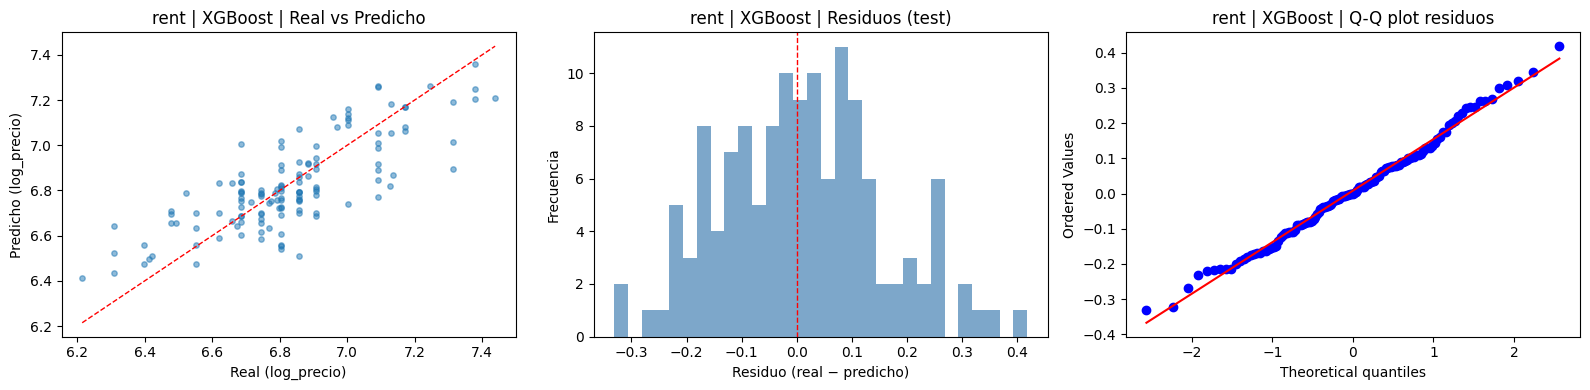

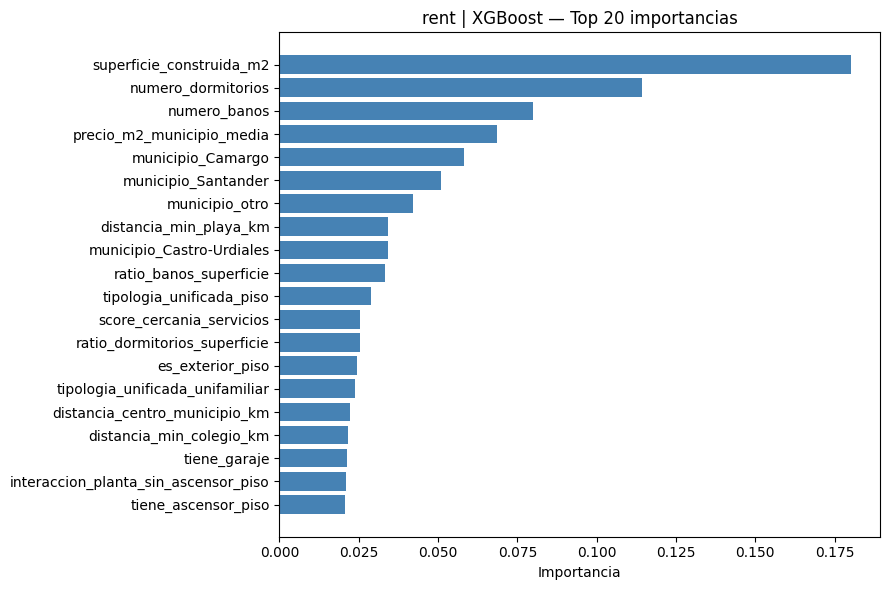

,feature,importance
0,superficie_construida_m2,0.180315
1,numero_dormitorios,0.114159
2,numero_banos,0.079953
11,precio_m2_municipio_media,0.068444
19,municipio_Camargo,0.058170
23,municipio_Santander,0.050953
25,municipio_otro,0.042223
8,distancia_min_playa_km,0.034337
20,municipio_Castro-Urdiales,0.034190
13,ratio_banos_superficie,0.033210


In [12]:
print("=" * 90)
print("DATASET: RENT")
print("=" * 90)

# ── Carga ──────────────────────────────────────────────────────────────────────
df_rent = pd.read_csv(RENT_PATH)
df_rent = df_rent[df_rent[TARGET_COL].notna() & df_rent["precio_m2"].notna()].copy()
print(f"Filas originales: {len(df_rent)}")

# ── Paso 1: eliminar vacacionales (precio_m2 alto) ────────────────────────────
mask_vac = df_rent["precio_m2"] <= RENT_PRECIO_M2_VACACIONAL
print(f"  Vacacionales eliminados (precio_m2 > {RENT_PRECIO_M2_VACACIONAL}): {(~mask_vac).sum()} ({(~mask_vac).mean()*100:.1f}%)")
df_rent = df_rent[mask_vac].copy()

# ── Paso 2: eliminar anomalías baratas (precio_m2 bajo) ───────────────────────
mask_min = df_rent["precio_m2"] >= RENT_PRECIO_M2_MIN
print(f"  Anomalías baratas eliminadas (precio_m2 < {RENT_PRECIO_M2_MIN}): {(~mask_min).sum()} ({(~mask_min).mean()*100:.1f}%)")
df_rent = df_rent[mask_min].copy()

# ── Paso 3: IQR×1.5 sobre log_precio ─────────────────────────────────────────
q1, q3 = df_rent[TARGET_COL].quantile([0.25, 0.75])
iqr = q3 - q1
mask_iqr = df_rent[TARGET_COL].between(q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr)
print(f"  IQR×{IQR_FACTOR} eliminados: {(~mask_iqr).sum()} ({(~mask_iqr).mean()*100:.1f}%)")
df_rent = df_rent[mask_iqr].copy()
print(f"Filas tras limpieza: {len(df_rent)}")

# ── Features (RENT_BASE_FEATURES + municipio_* OHE) ───────────────────────────
def build_X_rent(df: pd.DataFrame) -> tuple:
    df2 = df.copy()
    base = [f for f in RENT_BASE_FEATURES if f in df2.columns]
    mun_cols = sorted([c for c in df2.columns if c.startswith("municipio_")])
    if mun_cols:
        counts = df2[mun_cols].sum()
        small  = counts[counts < MIN_MUNI_OBS].index.tolist()
        if small:
            df2["municipio_otros"] = df2[small].max(axis=1)
            df2 = df2.drop(columns=small)
        mun_final = sorted(c for c in df2.columns if c.startswith("municipio_"))
    else:
        mun_final = []
    all_feats = base + [m for m in mun_final if m not in base]
    X = df2[all_feats].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X, all_feats

X_rent, feats_rent = build_X_rent(df_rent)
y_rent = df_rent[TARGET_COL].values
print(f"Features ({X_rent.shape[1]}): {feats_rent}")

# ── Split 80/20 ───────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_rent, y_rent, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_rent = XGBRegressor(**XGB_PARAMS_RENT)
model_rent.fit(X_train, y_train)

# ── CV-RMSE sobre train ───────────────────────────────────────────────────────
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    XGBRegressor(**XGB_PARAMS_RENT), X_train, y_train,
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
)
cv_rmse = float(-cv_scores.mean())

# ── Métricas ──────────────────────────────────────────────────────────────────
m_train = get_metrics(y_train, model_rent.predict(X_train))
m_test  = get_metrics(y_test,  model_rent.predict(X_test))

summary = pd.concat([
    m_train.assign(split="train"),
    pd.DataFrame({"split": ["CV"], "MSE": [None],
                  "RMSE": [round(cv_rmse, 5)],
                  "MAE": [None], "R2": [None], "MAPE": [None]}),
    m_test.assign(split="test"),
], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
print(f"\n{summary.to_string(index=False)}")

delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
print(f"\n  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")

plot_diagnostics(y_test, model_rent.predict(X_test), "rent | XGBoost")
plot_feature_importance(
    model_rent.feature_importances_, feats_rent,
    "rent | XGBoost — Top 20 importancias"
)